In [1]:
import pandas as pd
import numpy as np
import json
import os
from os.path import join
from tqdm import tqdm

In [2]:
folder = r'/home/ilya_treyvish/projects/lbnl_fdd/data/processed/SDAHU'

In [19]:
train_df = pd.read_csv(join(folder, 'train_df.csv'), index_col=[0, 1],
    parse_dates=[1])

In [7]:
train_df.index

MultiIndex([( 0, '2018-01-01 01:00:00'),
            ( 0, '2018-01-01 01:01:00'),
            ( 0, '2018-01-01 01:02:00'),
            ( 0, '2018-01-01 01:03:00'),
            ( 0, '2018-01-01 01:04:00'),
            ( 0, '2018-01-01 01:05:00'),
            ( 0, '2018-01-01 01:06:00'),
            ( 0, '2018-01-01 01:07:00'),
            ( 0, '2018-01-01 01:08:00'),
            ( 0, '2018-01-01 01:09:00'),
            ...
            (14, '2018-07-31 23:50:00'),
            (14, '2018-07-31 23:51:00'),
            (14, '2018-07-31 23:52:00'),
            (14, '2018-07-31 23:53:00'),
            (14, '2018-07-31 23:54:00'),
            (14, '2018-07-31 23:55:00'),
            (14, '2018-07-31 23:56:00'),
            (14, '2018-07-31 23:57:00'),
            (14, '2018-07-31 23:58:00'),
            (14, '2018-07-31 23:59:00')],
           names=['fault_type', 'Datetime'], length=4448700)

In [20]:
train_df["target"] = train_df.index.get_level_values(0)

In [21]:
train_df["target"].value_counts(normalize=True)

target
0     0.068609
1     0.068609
2     0.068609
3     0.068609
4     0.068609
5     0.068609
6     0.068609
7     0.068609
8     0.068609
9     0.068609
10    0.068609
11    0.068609
12    0.068609
14    0.068609
13    0.039477
Name: proportion, dtype: float64

SA_CFM


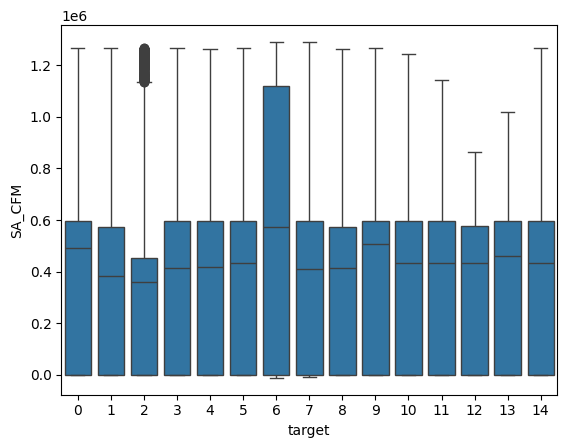

ZONE_TEMP_2


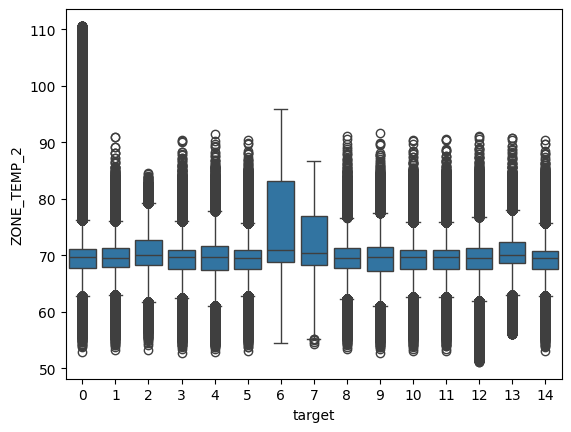

RA_DMPR


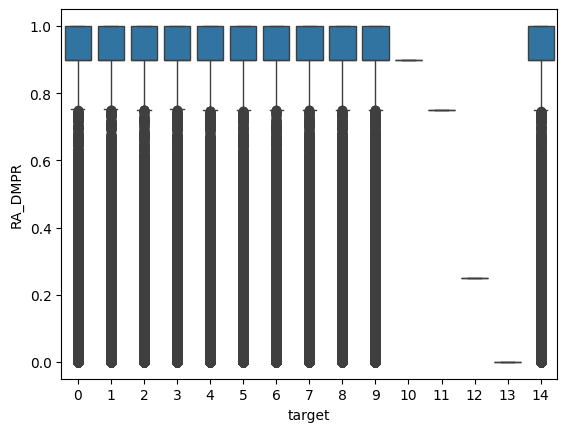

CHWC_VLV_DM


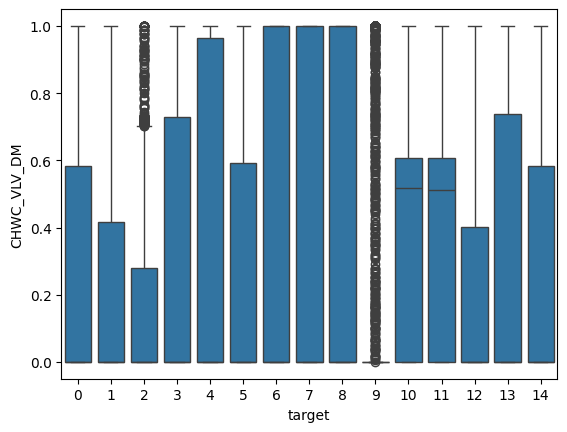

OA_DMPR_DM


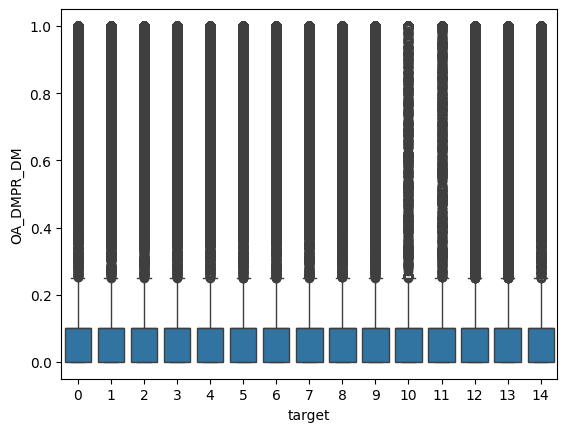

ZONE_TEMP_4


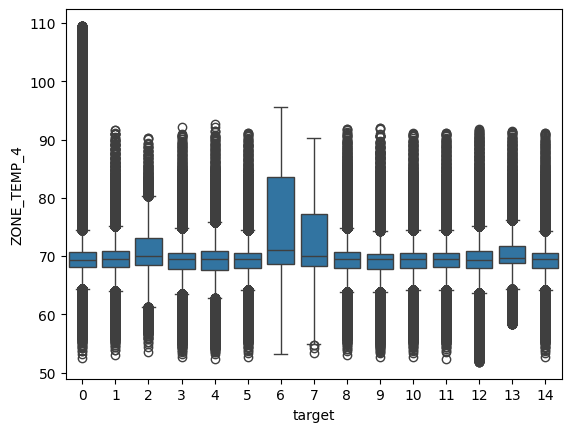

ZONE_TEMP_5


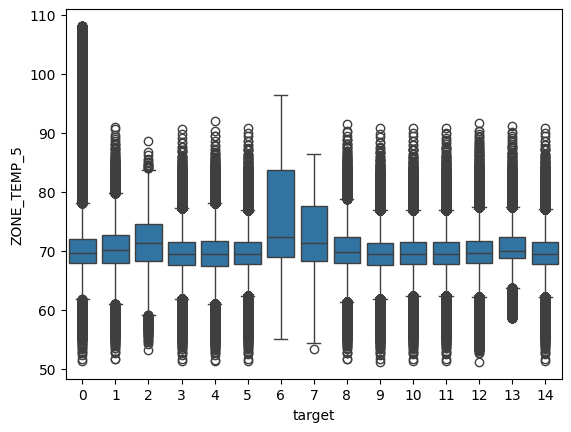

RF_WAT


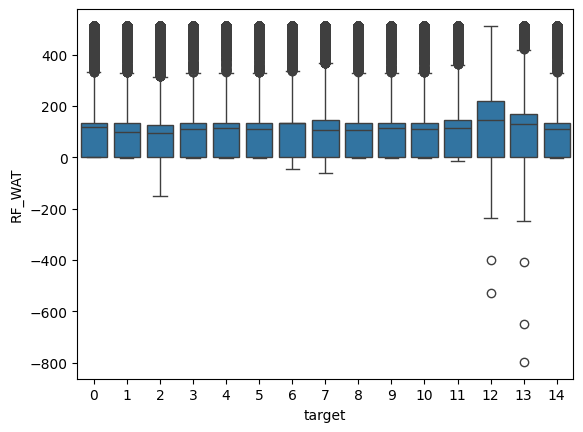

RA_TEMP


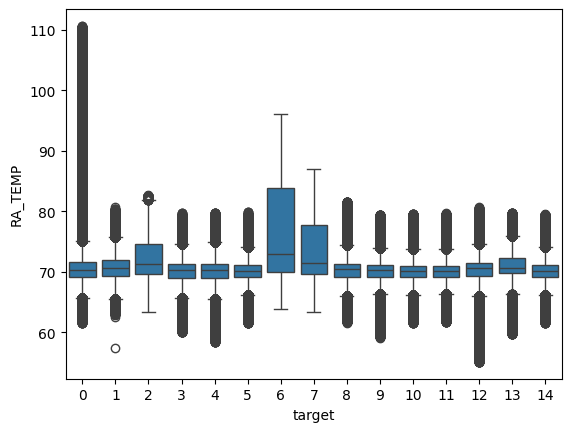

ZONE_TEMP_3


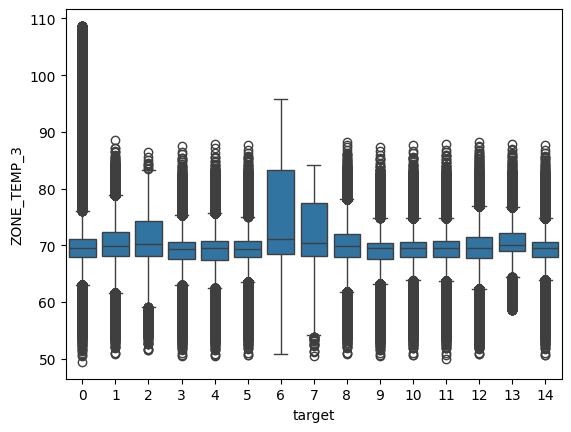

RF_SPD


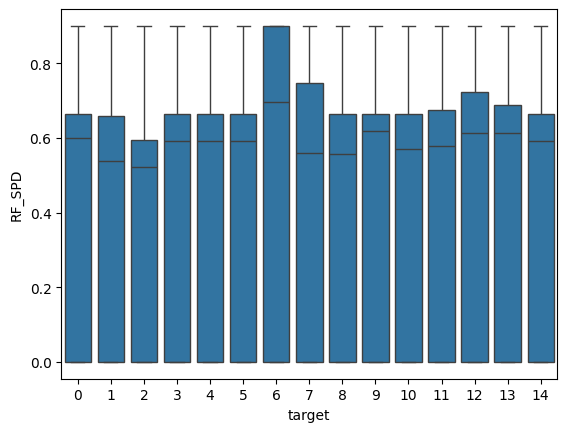

RF_CS


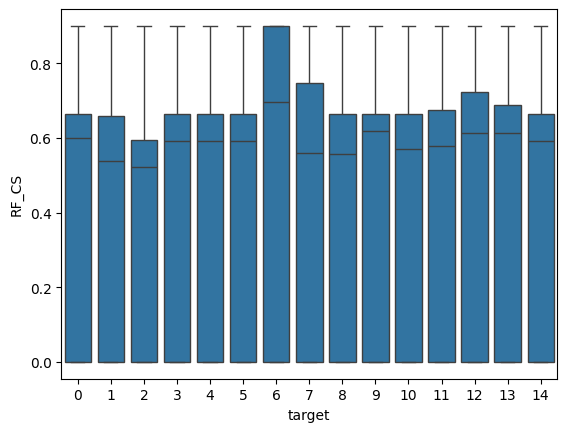

RA_DMPR_DM


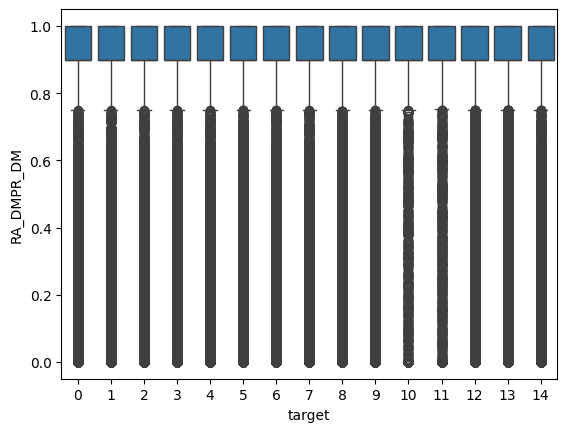

RA_CFM


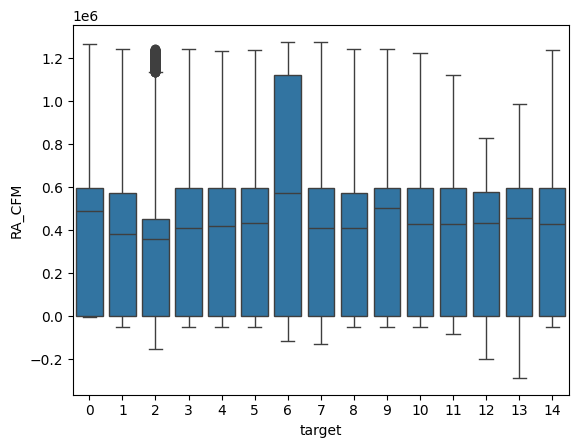

OA_TEMP


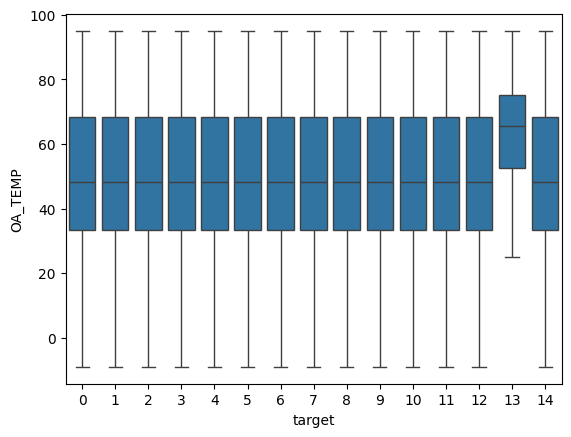

RF_SPD_DM


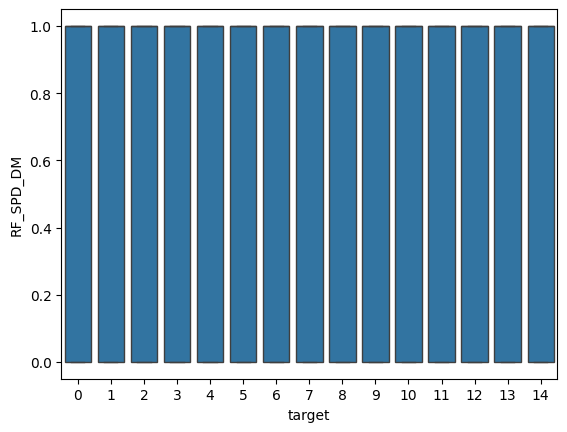

SF_CS


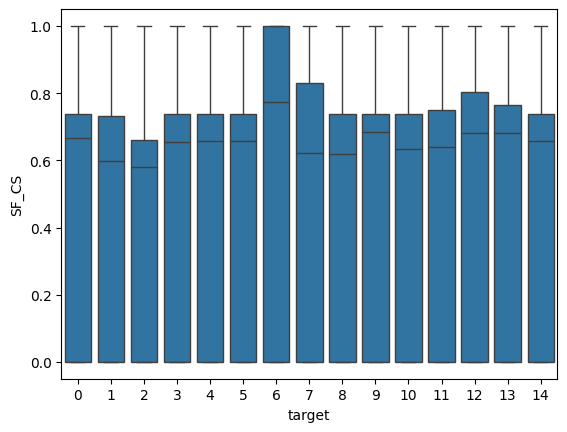

CHWC_VLV


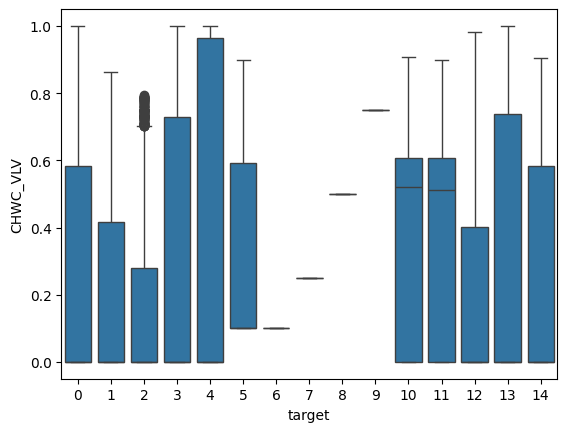

OA_DMPR


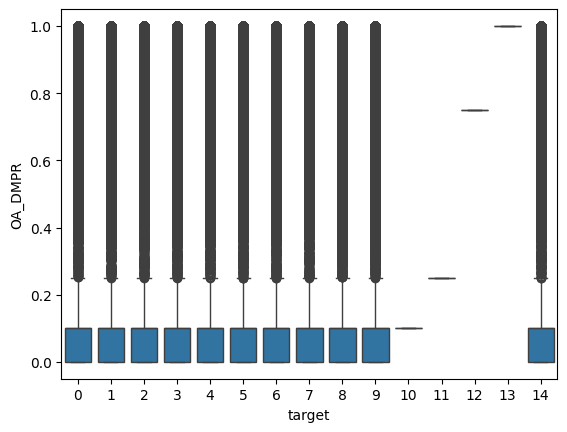

SA_TEMP


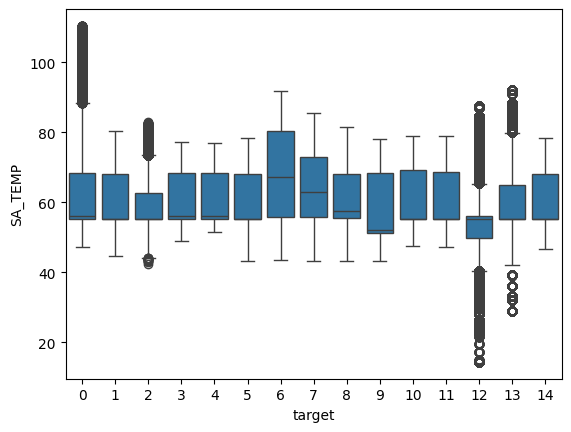

ZONE_TEMP_1


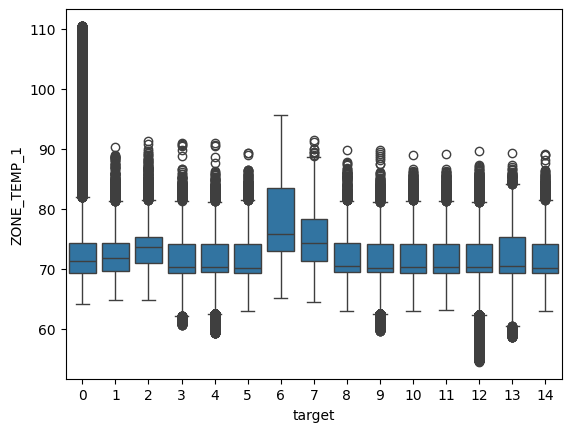

SF_SPD_DM


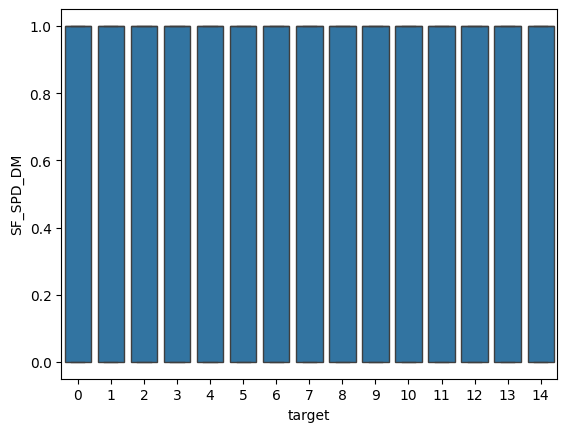

MA_TEMP


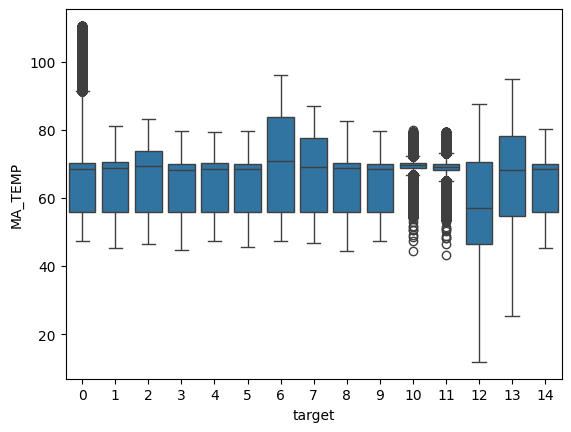

SF_WAT


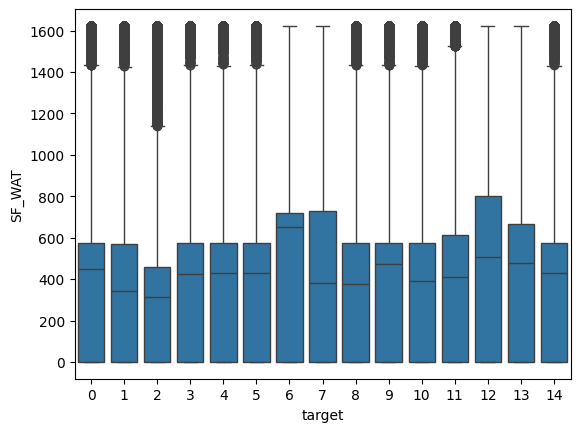

SYS_CTL


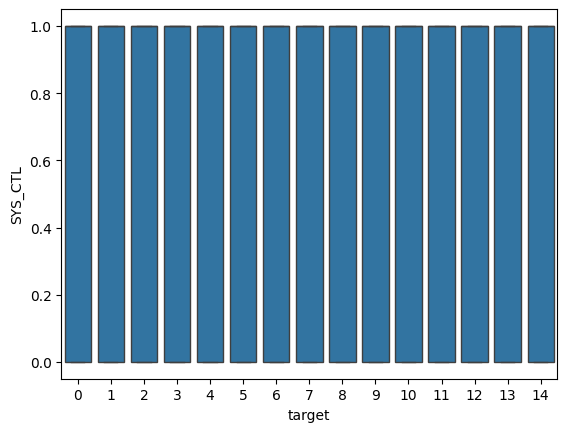

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


for feature in train_df.columns:
    if feature != "target":
        print(feature)
        sns.boxplot(x="target", y=feature, data=train_df)
        plt.show()

<Axes: >

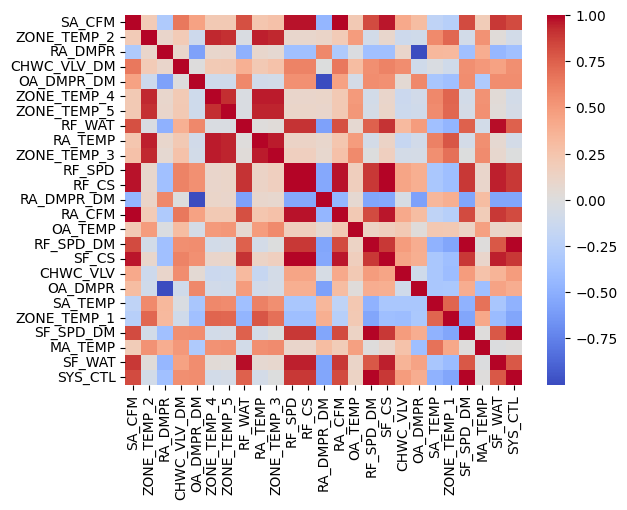

In [23]:
corr = train_df.drop(columns=["target"]).corr()
sns.heatmap(corr, cmap="coolwarm")

In [24]:
for feature in train_df.columns:
    if feature != "target":
        print(feature, train_df.groupby("target")[feature].nunique())
        

SA_CFM target
0     218162
1     234572
2     256039
3     221346
4     229835
5     226285
6     198656
7     251199
8     238342
9     228285
10    208137
11    209990
12    225584
13    121664
14    224934
Name: SA_CFM, dtype: int64
ZONE_TEMP_2 target
0     164359
1     158762
2     170360
3     164740
4     173647
5     161038
6     208660
7     191554
8     163409
9     171725
10    161496
11    161548
12    168015
13    116230
14    160674
Name: ZONE_TEMP_2, dtype: int64
RA_DMPR target
0     64691
1     64667
2     65459
3     64676
4     64502
5     64623
6     68030
7     68063
8     64738
9     64668
10        1
11        1
12        1
13        1
14    64600
Name: RA_DMPR, dtype: int64
CHWC_VLV_DM target
0     102847
1      99316
2     101480
3     104418
4      59736
5     103673
6       2786
7       4333
8       3186
9        417
10    154154
11    156673
12     83628
13     63474
14    102770
Name: CHWC_VLV_DM, dtype: int64
OA_DMPR_DM target
0     56508
1     56185
2     5

In [26]:
X_train = train_df.drop(columns=['target'])

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, train_df['target'])

importances = model.feature_importances_

KeyboardInterrupt: 